# Question 1: IT Support Cost Optimization

## Business Problem

The company handles approximately 2 million IT support tickets per year.

## Objectives

The main objectives of this analysis are:

- Reduce total IT support cost by 20%.
- Improve customer satisfaction above 4.2.
- Reduce unnecessary escalations.
- Optimize engineer allocation.
- Identify the major factors driving support costs.

In [27]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 100000

df = pd.DataFrame({
    "Ticket_ID": range(1, n + 1),

    "Issue_Category": np.random.choice(
        ["Network", "Software", "Hardware", "Security", "Infrastructure"],
        n
    ),

    "Priority": np.random.choice(
        ["Low", "Medium", "High", "Critical"],
        n,
        p=[0.30, 0.40, 0.25, 0.05]
    ),

    "Resolution_Time_Hours": np.round(
        np.random.gamma(2.5, 2, n), 2
    ),

    "Engineer_Hourly_Cost": np.random.choice(
        [400, 500, 600, 700, 800],
        n
    ),

    "Client_Type": np.random.choice(
        ["Small", "Medium", "Enterprise"],
        n,
        p=[0.30, 0.40, 0.30]
    ),

    "Escalation_Count": np.random.poisson(
        0.8, n
    ),

    "Customer_Satisfaction": np.round(
        np.random.uniform(3.0, 5.0, n), 1
    )
})

print("Sample dataset created successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Sample dataset created successfully!
Rows: 100000
Columns: 8


In [28]:
df.head()

,Ticket_ID,Issue_Category,Priority,Resolution_Time_Hours,Engineer_Hourly_Cost,Client_Type,Escalation_Count,Customer_Satisfaction
0,1,Security,Low,20.93,600,Medium,0,4.6
1,2,Infrastructure,Low,2.05,400,Small,1,3.3
2,3,Hardware,High,9.62,500,Small,1,3.7
3,4,Infrastructure,Low,1.15,500,Enterprise,2,4.1
4,5,Infrastructure,Low,1.94,500,Enterprise,0,3.6


In [29]:
df.shape

(100000, 8)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Ticket_ID              100000 non-null  int64  
 1   Issue_Category         100000 non-null  str    
 2   Priority               100000 non-null  str    
 3   Resolution_Time_Hours  100000 non-null  float64
 4   Engineer_Hourly_Cost   100000 non-null  int64  
 5   Client_Type            100000 non-null  str    
 6   Escalation_Count       100000 non-null  int32  
 7   Customer_Satisfaction  100000 non-null  float64
dtypes: float64(2), int32(1), int64(2), str(3)
memory usage: 5.7 MB


In [31]:
# Introduce realistic missing values for data-cleaning analysis

np.random.seed(42)

missing_rates = {
    "Resolution_Time_Hours": 0.10,
    "Engineer_Hourly_Cost": 0.08,
    "Escalation_Count": 0.05,
    "Customer_Satisfaction": 0.07
}

for column, rate in missing_rates.items():
    missing_indices = np.random.choice(
        df.index,
        size=int(len(df) * rate),
        replace=False
    )
    df.loc[missing_indices, column] = np.nan

print("Missing values introduced successfully!")

Missing values introduced successfully!


In [32]:
df.isnull().sum()

Ticket_ID                    0
Issue_Category               0
Priority                     0
Resolution_Time_Hours    10000
Engineer_Hourly_Cost      8000
Client_Type                  0
Escalation_Count          5000
Customer_Satisfaction     7000
dtype: int64

In [33]:
# Handle missing values using median imputation

numeric_columns = [
    "Resolution_Time_Hours",
    "Engineer_Hourly_Cost",
    "Escalation_Count",
    "Customer_Satisfaction"
]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values handled successfully!")

Missing values handled successfully!


In [34]:
df.isnull().sum()

Ticket_ID                0
Issue_Category           0
Priority                 0
Resolution_Time_Hours    0
Engineer_Hourly_Cost     0
Client_Type              0
Escalation_Count         0
Customer_Satisfaction    0
dtype: int64

In [35]:
# Check for duplicate tickets

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [36]:
df.describe()

,Ticket_ID,Resolution_Time_Hours,Engineer_Hourly_Cost,Escalation_Count,Customer_Satisfaction
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,4.928491,600.415000,0.813040,3.998922
std,28867.657797,2.998419,135.326682,0.873953,0.557710
min,1.000000,0.020000,400.000000,0.000000,3.000000
25%,25000.750000,2.850000,500.000000,0.000000,3.500000
50%,50000.500000,4.360000,600.000000,1.000000,4.000000
75%,75000.250000,6.290000,700.000000,1.000000,4.500000
max,100000.000000,33.380000,800.000000,7.000000,5.000000


In [37]:
# Calculate total support cost for each ticket

df["Total_Support_Cost"] = (
    df["Resolution_Time_Hours"] * df["Engineer_Hourly_Cost"]
)

print("Total support cost calculated successfully!")

Total support cost calculated successfully!


In [38]:
df[["Ticket_ID", "Resolution_Time_Hours", 
    "Engineer_Hourly_Cost", "Total_Support_Cost"]].head()

,Ticket_ID,Resolution_Time_Hours,Engineer_Hourly_Cost,Total_Support_Cost
0,1,20.93,600.0,12558.0
1,2,2.05,400.0,820.0
2,3,9.62,500.0,4810.0
3,4,1.15,500.0,575.0
4,5,1.94,600.0,1164.0


In [39]:
# Calculate overall support cost

total_cost = df["Total_Support_Cost"].sum()
average_cost = df["Total_Support_Cost"].mean()

print(f"Total Support Cost: ₹{total_cost:,.2f}")
print(f"Average Cost per Ticket: ₹{average_cost:,.2f}")

Total Support Cost: ₹295,858,500.00
Average Cost per Ticket: ₹2,958.59


In [40]:
# Analyze support cost by issue category

category_cost = (
    df.groupby("Issue_Category")["Total_Support_Cost"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

category_cost

,sum,mean,count
Issue_Category,,,
Infrastructure,59901146.0,2967.312924,20187
Software,59200435.0,2947.935216,20082
Security,59102005.0,2957.910265,19981
Network,58964854.0,2945.591667,20018
Hardware,58690060.0,2974.359416,19732


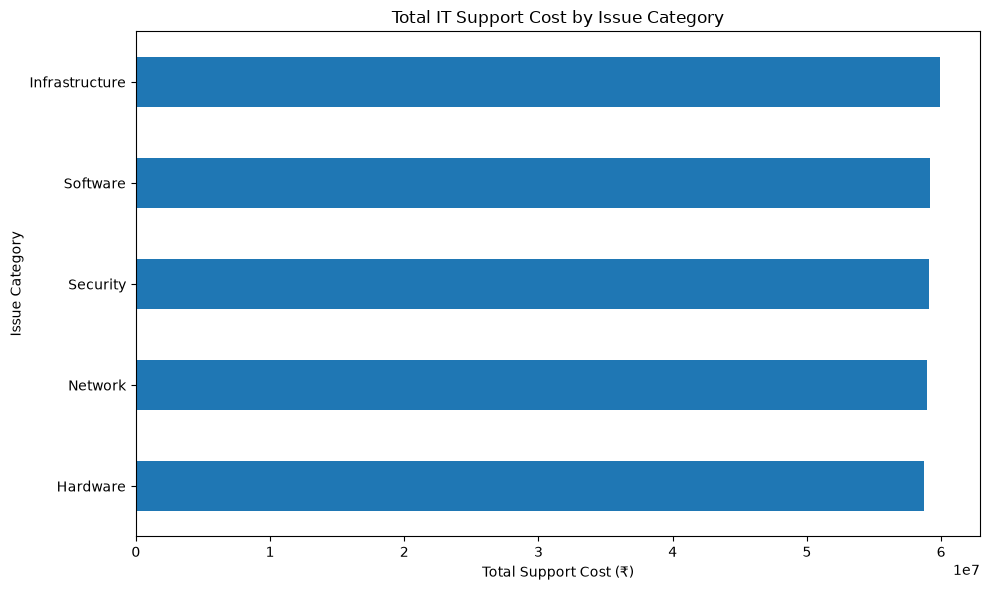

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

category_cost["sum"].sort_values().plot(kind="barh")

plt.title("Total IT Support Cost by Issue Category")
plt.xlabel("Total Support Cost (₹)")
plt.ylabel("Issue Category")

plt.tight_layout()
plt.show()

In [42]:
# Analyze support cost by ticket priority

priority_cost = (
    df.groupby("Priority")["Total_Support_Cost"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

priority_cost

,sum,mean,count
Priority,,,
Medium,117966003.0,2945.027037,40056
Low,88521814.0,2965.654260,29849
High,74678956.0,2969.814523,25146
Critical,14691727.0,2968.625379,4949


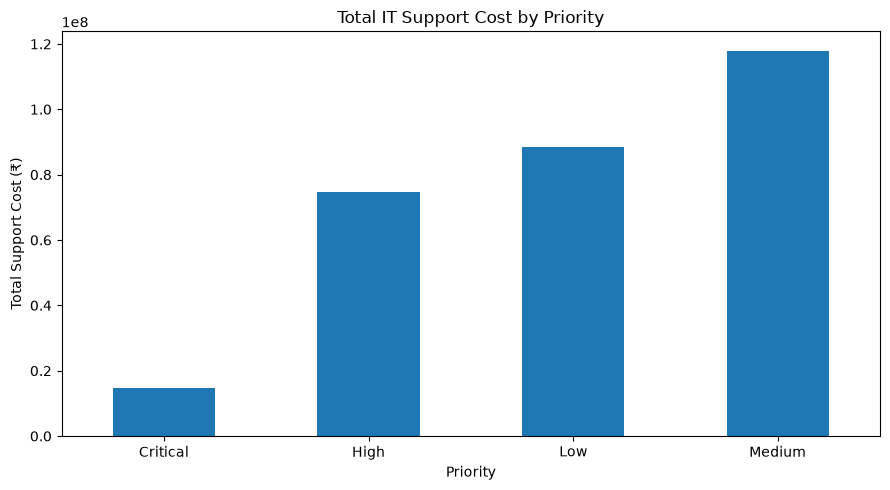

In [43]:
# Visualize total support cost by priority

plt.figure(figsize=(9, 5))

priority_cost["sum"].sort_values().plot(kind="bar")

plt.title("Total IT Support Cost by Priority")
plt.xlabel("Priority")
plt.ylabel("Total Support Cost (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [44]:
# Analyze average resolution time by issue category

resolution_analysis = (
    df.groupby("Issue_Category")["Resolution_Time_Hours"]
    .agg(["mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

resolution_analysis


,mean,median,max
Issue_Category,,,
Hardware,4.949807,4.36,29.59
Infrastructure,4.938901,4.36,30.37
Security,4.921983,4.36,29.87
Software,4.917960,4.36,32.29
Network,4.914041,4.36,33.38


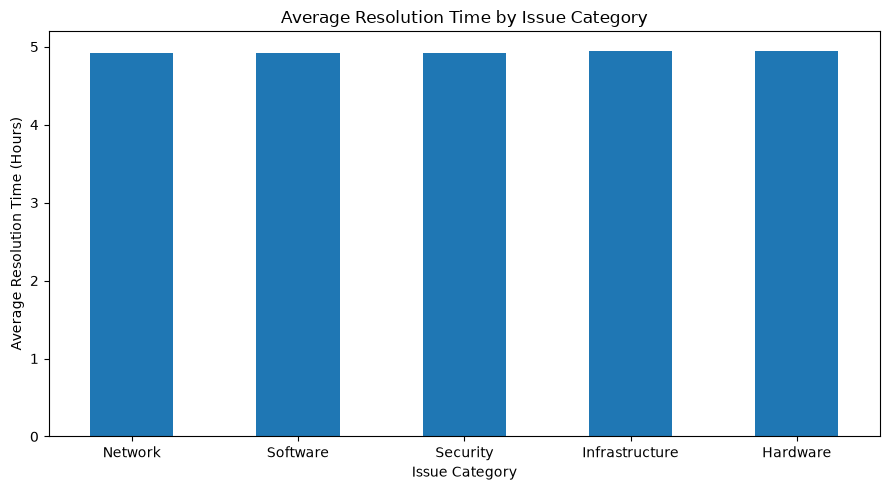

In [45]:
# Visualize average resolution time by issue category

plt.figure(figsize=(9, 5))

resolution_analysis["mean"].sort_values().plot(kind="bar")

plt.title("Average Resolution Time by Issue Category")
plt.xlabel("Issue Category")
plt.ylabel("Average Resolution Time (Hours)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [46]:
# Analyze escalations by issue category

escalation_analysis = (
    df.groupby("Issue_Category")["Escalation_Count"]
    .agg(["mean", "sum", "count"])
    .sort_values("mean", ascending=False)
)

escalation_analysis

,mean,sum,count
Issue_Category,,,
Network,0.816865,16352.0,20018
Software,0.815556,16378.0,20082
Hardware,0.813704,16056.0,19732
Infrastructure,0.810373,16359.0,20187
Security,0.808718,16159.0,19981


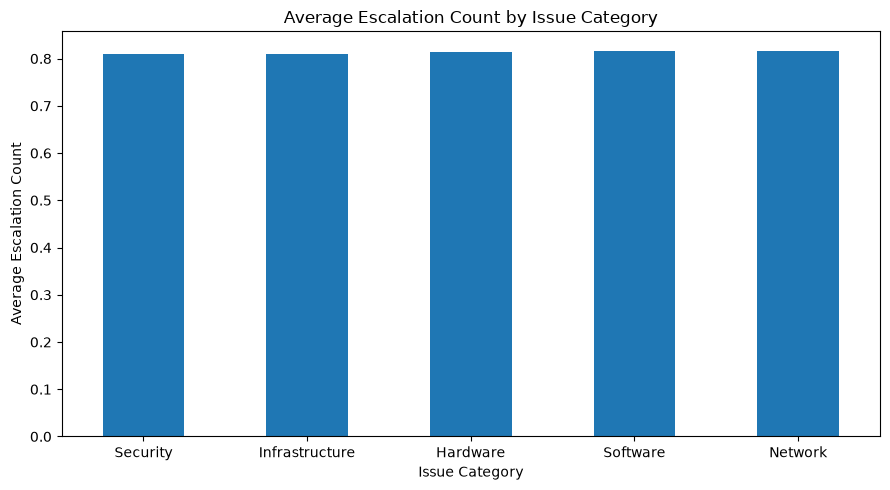

In [47]:
# Visualize average escalations by issue category

plt.figure(figsize=(9, 5))

escalation_analysis["mean"].sort_values().plot(kind="bar")

plt.title("Average Escalation Count by Issue Category")
plt.xlabel("Issue Category")
plt.ylabel("Average Escalation Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [48]:
# Analyze customer satisfaction by issue category

satisfaction_analysis = (
    df.groupby("Issue_Category")["Customer_Satisfaction"]
    .agg(["mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

satisfaction_analysis

,mean,median,min,max
Issue_Category,,,,
Security,4.004274,4.0,3.0,5.0
Software,4.001190,4.0,3.0,5.0
Hardware,3.999752,4.0,3.0,5.0
Infrastructure,3.995022,4.0,3.0,5.0
Network,3.994420,4.0,3.0,5.0


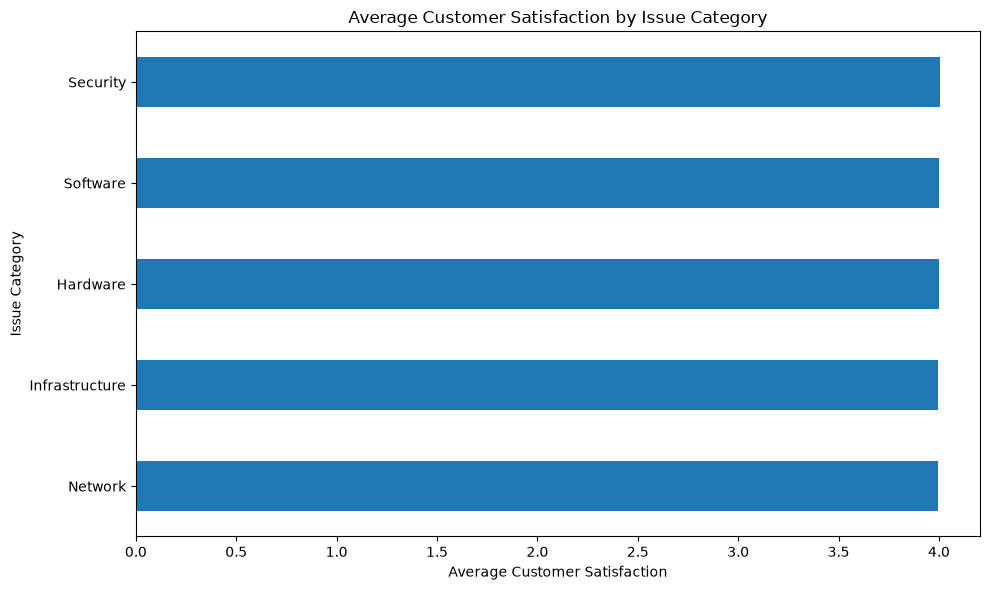

In [49]:
# Customer satisfaction by issue category

plt.figure(figsize=(10, 6))

satisfaction_analysis["mean"].sort_values().plot(kind="barh")

plt.title("Average Customer Satisfaction by Issue Category")
plt.xlabel("Average Customer Satisfaction")
plt.ylabel("Issue Category")

plt.tight_layout()
plt.show()

## Key Insights

1. Infrastructure has the highest total support cost.
2. Medium-priority tickets contribute the highest overall support cost.
3. Network issues have the highest maximum resolution time.
4. Customer satisfaction is relatively consistent across all issue categories.
5. Reducing resolution time and optimizing engineer allocation can help lower support costs.

## Business Recommendations

1. Prioritize cost reduction in Infrastructure support.
2. Optimize engineer allocation for Medium-priority tickets.
3. Reduce resolution time for Network-related issues.
4. Use automation and self-service solutions for repetitive support issues.
5. Monitor support costs regularly to achieve the target of 20% cost reduction.

## Conclusion

The analysis shows that IT support costs are significant across all issue categories and priorities. Infrastructure has the highest total support cost, while Medium-priority tickets contribute the largest overall cost. Network issues have the highest maximum resolution time. By optimizing engineer allocation, reducing resolution time, and using automation for repetitive issues, the company can work toward reducing total IT support costs by 20%.